Link for n doors part - http://educ.jmu.edu/~lucassk/Papers/MontyFinal2.pdf (SLM approach) 
                    and https://math.stackexchange.com/questions/608957/monty-hall-problem-extended

Describe the Monty-Hall problem in terms of probabilities with 3 doors and several extensions 
of the original problem. The game show went like this: 
1. There  are  3  doors,  behind  one  door is  a  prize,  behind  each  of the  other  2  doors is  a 
goat. 
2. You (the contestant) picks a door. 
3. The show host opens one of the doors you did not choose and reveals a goat. 
4. You  have  now  the  opportunity  to  switch  your  pick  or  stick  with  your  choice  from 
before 
5. The host reveals the prize.

1.  Questions: 
    1. What is the exact probability of winning a prize with not switching? [2 points] 
    1. What is the exact probability of winning a prize with switching? [4 points] 
2.  We  now  extend  the  Monty-Hall  problem  to  𝑛  doors,  without  changing  the  procedure 
above. Questions: 
    1. What is the exact probability of winning a prize with not switching? [4 points] 
    2. What is the exact probability of winning a prize with always switching? [8 points] 

3.  We have a Monty-Hall problem with 𝑛 doors, we change the procedure to: 
    1.  There are 𝑛 doors, and behind one door is a prize, and behind each of the other (𝑛 −1) doors is a goat 
    2.  You (the contestant) pick a door 
    3.  The show host opens one of the doors you did not pick and reveals a goat. 
    4.  You now have the opportunity to switch your pick or stick with your choice from before 
    5.  The show host opens another door with a goat, and you can again switch (or not) 
    6.  The host reveals the prize once all except 2 doors are opened.

Questions: 
1. What is the probability of winning a prize with never switching? [6 points]
2. What is the probability of winning a prize with always switching? 


### Always switching with probability 1

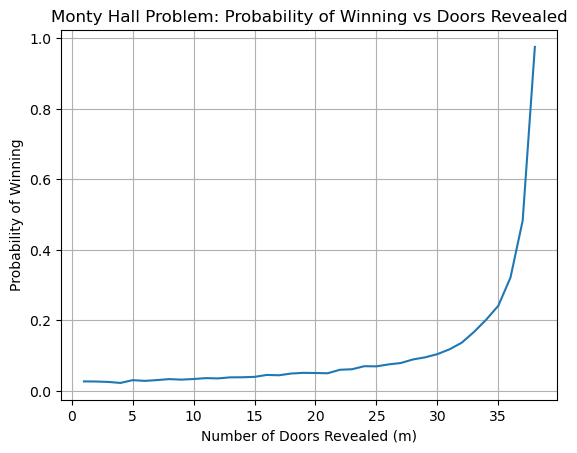

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_Monty_Hall(n, k, N): 
    wins = 0
    for _ in range(N):
        prize_door = np.random.randint(1, n + 1)
        selected_door = np.random.randint(1, n + 1)
        revealed_doors = set()

        # Determining the k doors to be revealed
        while len(revealed_doors) < k:
            m = np.random.randint(1, n + 1)
            if m != prize_door and m != selected_door:
                revealed_doors.add(m)

        # Switching door after the doors are revealed
        remaining_doors = set(range(1, n + 1)) - revealed_doors - {selected_door}
        switched_door = np.random.choice(list(remaining_doors))

        if switched_door == prize_door:
            wins += 1            

    return wins / N

N = 10000
n = 40
k_max = n - 2

# Calculating probabilities for k doors opened (1 at a time)
win_probability = []
for k in range(1, k_max + 1):
    win_probability.append(simulate_Monty_Hall(n, k, N))

# Plotting the results
plt.plot(range(1, k_max + 1), win_probability)
plt.xlabel("Number of Doors Revealed (m)")
plt.ylabel("Probability of Winning")
plt.title("Monty Hall Problem: Probability of Winning vs Doors Revealed")
plt.grid(True)
plt.show()



3. Show a simulation where the contestant is switching only with probability 𝑝 (the graph should show the probability of switching 𝑝 versus probability of winning).

### Switching with probability p

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


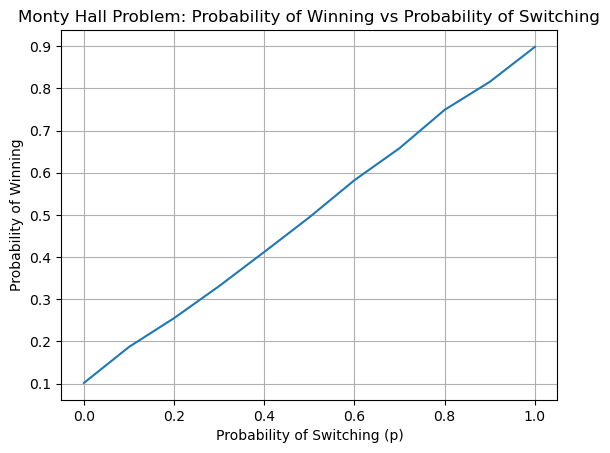

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_Monty_Hall(n, k, N, p): 
    wins = 0
    for _ in range(N):
        prize_door = np.random.randint(1, n + 1)
        selected_door = np.random.randint(1, n + 1)
        revealed_doors = set()

        # Determining the k doors to be revealed
        while len(revealed_doors) < k:
            m = np.random.randint(1, n + 1)
            if m != prize_door and m != selected_door:
                revealed_doors.add(m)

        # Deciding whether to switch or not
        if np.random.random() <= p:
            remaining_doors = set(range(1, n + 1)) - revealed_doors - {selected_door}
            selected_door = np.random.choice(list(remaining_doors))

        if selected_door == prize_door:
            wins += 1            

    return wins / N

N = 10000
n = 50
k_max = n - 2
p_values = np.linspace(0, 1, 11)

# Calculating probabilities for different values of p
win_probability = []
for p in p_values:
    win_probability.append(simulate_Monty_Hall(n, k_max, N, p))  # Fixed k=1 for simplicity

# Plotting the results
plt.plot(p_values, win_probability)
plt.xlabel("Probability of Switching (p)")
plt.ylabel("Probability of Winning")
plt.title("Monty Hall Problem: Probability of Winning vs Probability of Switching")
plt.grid(True)
plt.show()


4. Extend the problem of the question (3) using simulation. The host can reveal up to 𝑚 doors 
at one time, 𝑚 is drawn uniformly from the remaining closed doors with no prize behind 
them.  Show two  graphs,  that  plots  a  contour  plot  with  𝑛  vs. 𝑚  and  contour  color is the 
probability of winning for the probabilities of switching of 𝑝 = 0.5 and 𝑝 = 1

## Part 4 

m doors can be revealed at a time

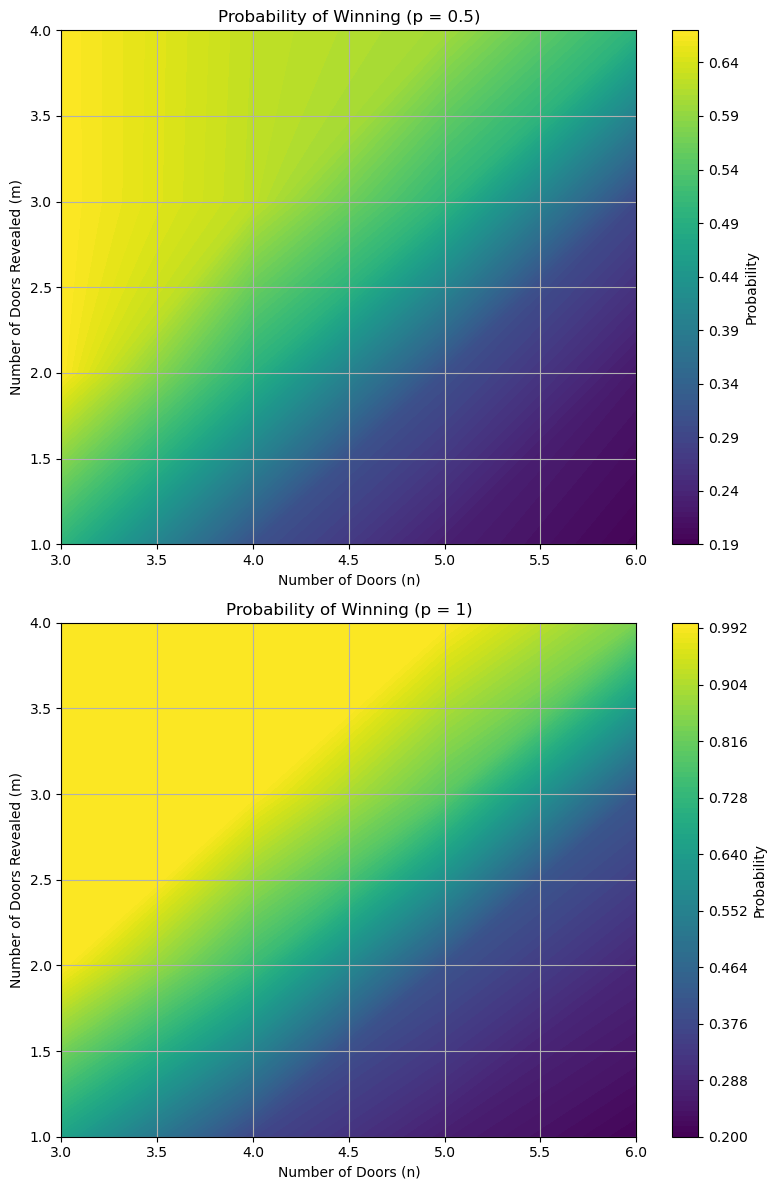

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_Monty_Hall(n, k, N, p, m): 
    wins = 0
    for _ in range(N):
        prize_door = np.random.randint(1, n + 1)
        selected_door = np.random.randint(1, n + 1)
        revealed_doors = set()

        # Determining the m doors to be revealed
        remaining_closed_doors = set(range(1, n + 1)) - {prize_door, selected_door}
        newly_revealed_doors = np.random.choice(list(remaining_closed_doors), size=min(m, len(remaining_closed_doors)), replace=False)
        revealed_doors.update(newly_revealed_doors)

        # Deciding whether to switch or not
        if np.random.random() <= p:
            remaining_doors = set(range(1, n + 1)) - revealed_doors - {selected_door}
            if len(remaining_doors) > 0:
                selected_door = np.random.choice(list(remaining_doors))

        if selected_door == prize_door:
            wins += 1

    return wins / N

N = 10000
n = 6
n_values = np.arange(3, n + 1)
m_values = np.arange(1, n - 1)
p_values = [0.5, 1]

# Calculate the probabilities for different values of n, m, and p
win_probabilities = np.zeros((len(p_values), len(n_values), len(m_values)))
for i, p in enumerate(p_values):
    for j, n in enumerate(n_values):
        for k, m in enumerate(m_values):
            win_probabilities[i, j, k] = simulate_Monty_Hall(n, n - 2, N, p, m)

# Plot the contour plots
fig, axes = plt.subplots(len(p_values), 1, figsize=(8, 6 * len(p_values)))

for i, p in enumerate(p_values):
    ax = axes[i]
    X, Y = np.meshgrid(n_values, m_values)
    Z = win_probabilities[i].T

    cf = ax.contourf(X, Y, Z, levels=100, cmap='viridis')
    ax.set_xlabel('Number of Doors (n)')
    ax.set_ylabel('Number of Doors Revealed (m)')
    ax.set_title(f'Probability of Winning (p = {p})')
    ax.grid(True)
    cbar = plt.colorbar(cf, ax=ax)
    cbar.set_label('Probability')
    
plt.tight_layout()
plt.show()
